[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatheusSilveiraVicente/case-especialista-dados/blob/main/notebooks/04_demo_clip.ipynb)

# Demo híbrida de scoring visual

A demonstração gera 32 banners sintéticos com atributos balanceados e sorteados separadamente. Ela compara CLIP zero-shot, CLIP com poucos rótulos e medidas quantitativas simples; não usa banners reais nem mede performance comercial.

## Preparação reproduzível

No Google Colab, a célula clona o repositório público e instala as dependências. Localmente, execute a partir da raiz do repositório.

In [1]:
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "MatheusSilveiraVicente/case-especialista-dados"
if IN_COLAB:
    pasta_repo = Path("/content/case-especialista-dados")
    if not pasta_repo.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(pasta_repo)], check=True)
    os.chdir(pasta_repo)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "pillow", "scikit-learn"], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
from IPython.display import Image as IPyImage, display
from src.clip_demo import (
    ROTULOS_ZERO_SHOT, atributos_simples, avaliar_zero_shot, clusters,
    composicao_clusters, dispositivo, embeddings, gerar_banners,
    linear_probe, medir_latencia, plotar_mapa_2d, plotar_vizinhos,
    probe_atributos_simples, tabela_hibrida, vizinhos, zero_shot,
    zero_shot_siglip2,
)

SEED = 42
np.random.seed(SEED)
pasta = Path("data/banners_sinteticos")
gabarito = gerar_banners(pasta, n=32, seed=SEED)
caminhos = [pasta / nome for nome in gabarito["arquivo"]]
Path("reports/metrics").mkdir(parents=True, exist_ok=True)
display(gabarito.head())

,arquivo,fundo,cor_dominante,mensagem,preco_visivel,elemento_produto
0,banner_547345cae1.png,escuro,verde,promocional,sim,sim
1,banner_03ddf85112.png,escuro,rosa,lançamento,sim,sim
2,banner_cdf56f9773.png,claro,rosa,promocional,sim,não
3,banner_9943b4bc88.png,escuro,dourado,promocional,não,não
4,banner_720b4b48fe.png,escuro,verde,promocional,não,sim


## Embeddings e latência aquecida

A medição aquece o modelo antes do cronômetro, repete a inferência em lote e um banner por chamada, e projeta o tempo de 10 mil banners.

In [2]:
latencia = medir_latencia(caminhos, repeticoes=5, aquecimentos=1)
latencia.to_csv("reports/metrics/clip_latencia.csv", index=False)
display(latencia.round(3))
emb = embeddings(caminhos)
print(f"Dispositivo: {dispositivo().upper()} | embeddings: {emb.shape} | norma média: {np.linalg.norm(emb, axis=1).mean():.4f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

,modo,repeticoes,banners_por_repeticao,ms_por_banner_media,ms_por_banner_min,ms_por_banner_max,projecao_10_mil_minutos_media,projecao_10_mil_minutos_min,projecao_10_mil_minutos_max
0,lote,5,32,32.324,30.375,34.272,5.387,5.063,5.712
1,individual,5,32,48.072,47.396,49.241,8.012,7.899,8.207


Dispositivo: CPU | embeddings: (32, 512) | norma média: 1.0000


## CLIP zero-shot

O CLIP original compara cada imagem com prompts em inglês, sem consultar o gabarito.

In [3]:
previsto = zero_shot(emb, ROTULOS_ZERO_SHOT)
acuracia = avaliar_zero_shot(previsto, gabarito)
acuracia.to_csv("reports/metrics/clip_zero_shot_acuracia.csv", index=False)
display(acuracia.style.format({"acuracia": "{:.1%}"}))

,atributo,acuracia,n
0,fundo,59.4%,32
1,cor_dominante,100.0%,32
2,mensagem,31.2%,32
3,preco_visivel,50.0%,32
4,elemento_produto,50.0%,32


## Agrupamento sem rótulos

O k-means cria quatro grupos sem consultar o gabarito. PCA é usado apenas para visualizar o espaço.

,cluster,atributo,valor,quantidade,proporcao
9,0,cor_dominante,rosa,4,0.444444
8,0,cor_dominante,azul,3,0.333333
10,0,cor_dominante,verde,2,0.222222
35,0,elemento_produto,sim,5,0.555556
34,0,elemento_produto,não,4,0.444444
0,0,fundo,claro,6,0.666667
1,0,fundo,escuro,3,0.333333
22,0,mensagem,promocional,9,1.000000
27,0,preco_visivel,sim,6,0.666667
26,0,preco_visivel,não,3,0.333333


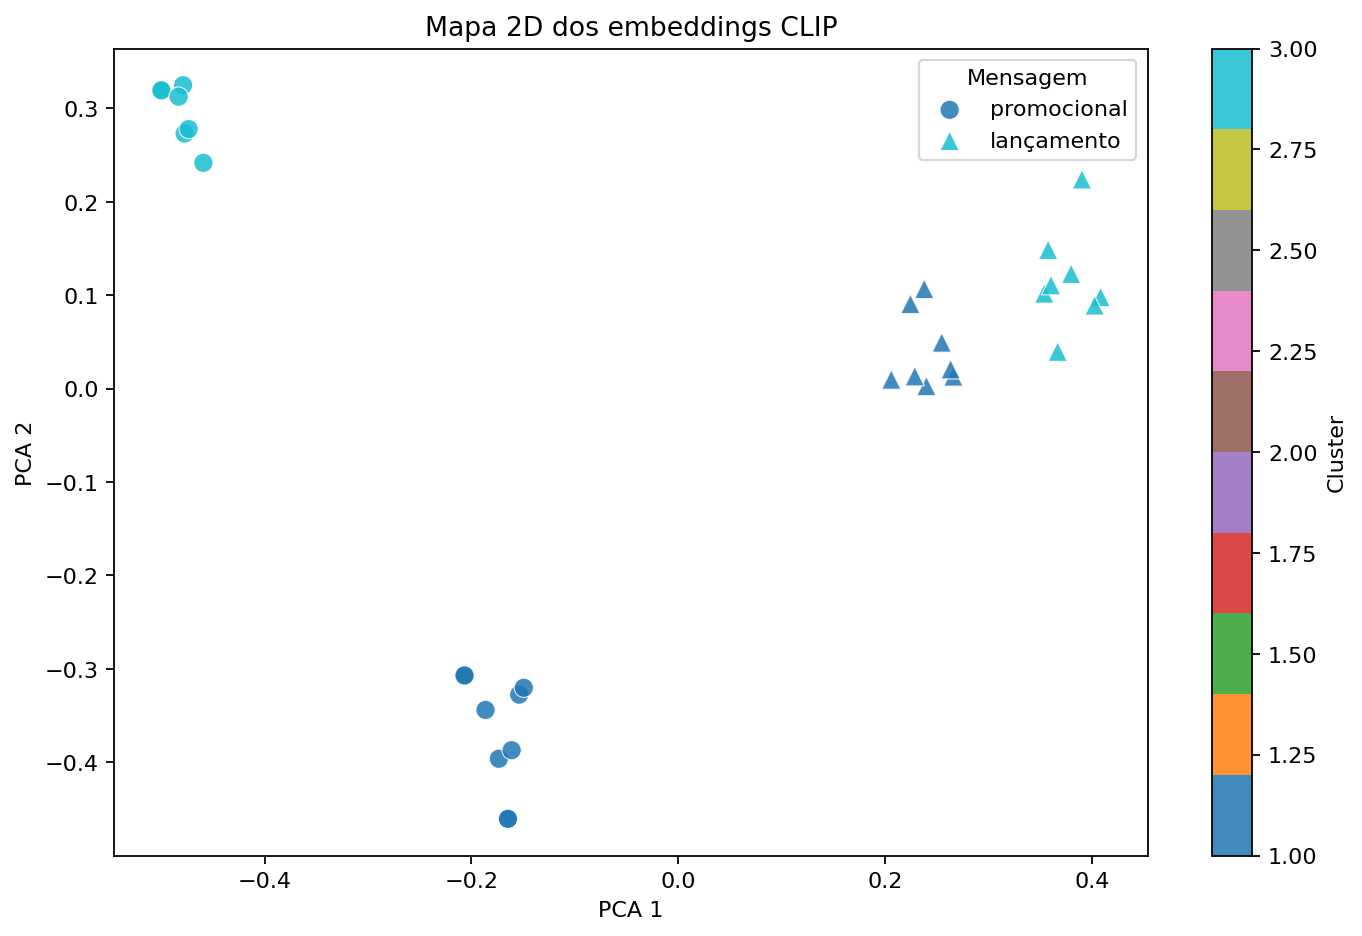

In [4]:
rotulos_cluster = clusters(emb, k=4, seed=SEED)
composicao = composicao_clusters(rotulos_cluster, gabarito)
composicao.to_csv("reports/metrics/clip_clusters.csv", index=False)
plotar_mapa_2d(emb, rotulos_cluster, gabarito)
display(composicao.sort_values(["cluster", "atributo", "proporcao"], ascending=[True, True, False]))
display(IPyImage(filename="reports/figures/clip_mapa_2d.png"))

## Comparação híbrida em 20 partições

A validação usa quatro folds: em cada rodada, treina com 24 banners e testa nos 8 restantes. O processo é repetido em 20 partições fixas; a tabela mostra média, mínimo e máximo. As medidas simples incluem brilho, contraste, cor média, bordas de texto, caixa de preço e pixels do frasco.

In [5]:
probe_clip = linear_probe(emb, gabarito, folds=4, seed=SEED, particoes=20)
medidas = atributos_simples(caminhos)
probe_simples = probe_atributos_simples(medidas, gabarito, folds=4, seed=SEED, particoes=20)
comparativo = tabela_hibrida(acuracia, probe_clip, probe_simples)
probe_clip.to_csv("reports/metrics/clip_linear_probe.csv", index=False)
medidas.to_csv("reports/metrics/clip_atributos_simples.csv", index=False)
comparativo.to_csv("reports/metrics/clip_hibrido.csv", index=False)
display(comparativo.style.format({coluna: "{:.1%}" for coluna in comparativo.columns if coluna != "atributo"}))

,atributo,clip_zero_shot,clip_mais_24_rotulos_media,clip_mais_24_rotulos_min,clip_mais_24_rotulos_max,atributos_simples_media,atributos_simples_min,atributos_simples_max
0,fundo,59.4%,71.9%,53.1%,87.5%,100.0%,100.0%,100.0%
1,cor_dominante,100.0%,94.8%,87.5%,96.9%,95.0%,90.6%,100.0%
2,mensagem,31.2%,100.0%,100.0%,100.0%,55.5%,46.9%,65.6%
3,preco_visivel,50.0%,54.7%,37.5%,62.5%,100.0%,100.0%,100.0%
4,elemento_produto,50.0%,51.6%,34.4%,65.6%,100.0%,100.0%,100.0%


**Leitura**

- O CLIP captura mensagem e cor; os atributos quantitativos resolvem fundo, caixa de preço e frasco. A combinação é mais robusta que qualquer coluna isolada.
- Os atributos do gabarito são balanceados e sorteados separadamente. Preço e frasco voltam para perto do acaso no probe CLIP, sem a relação de paridade do desenho anterior.
- Os banners são sintéticos e simples: 100% aqui valida o componente, não implica performance em banners reais.

## SigLIP 2 multilíngue, quando disponível

A célula usa prompts em português. Localmente, consulta somente o cache para não forçar um download; no Colab, permite baixar os pesos. A indisponibilidade é registrada sem interromper a demo principal.

In [6]:
try:
    previsto_siglip2 = zero_shot_siglip2(caminhos, local_files_only=not IN_COLAB)
    acuracia_siglip2 = avaliar_zero_shot(previsto_siglip2, gabarito)
    acuracia_siglip2.to_csv("reports/metrics/clip_siglip2_zero_shot.csv", index=False)
    display(acuracia_siglip2.style.format({"acuracia": "{:.1%}"}))
except Exception as erro_siglip2:
    print(f"SigLIP 2 indisponível: {type(erro_siglip2).__name__}: {erro_siglip2}")

SigLIP 2 indisponível: OSError: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.


## Busca por vizinhos

A similaridade de cosseno recupera os três banners mais próximos da consulta.

Consulta e vizinhos: [0, 4, 5, 24]


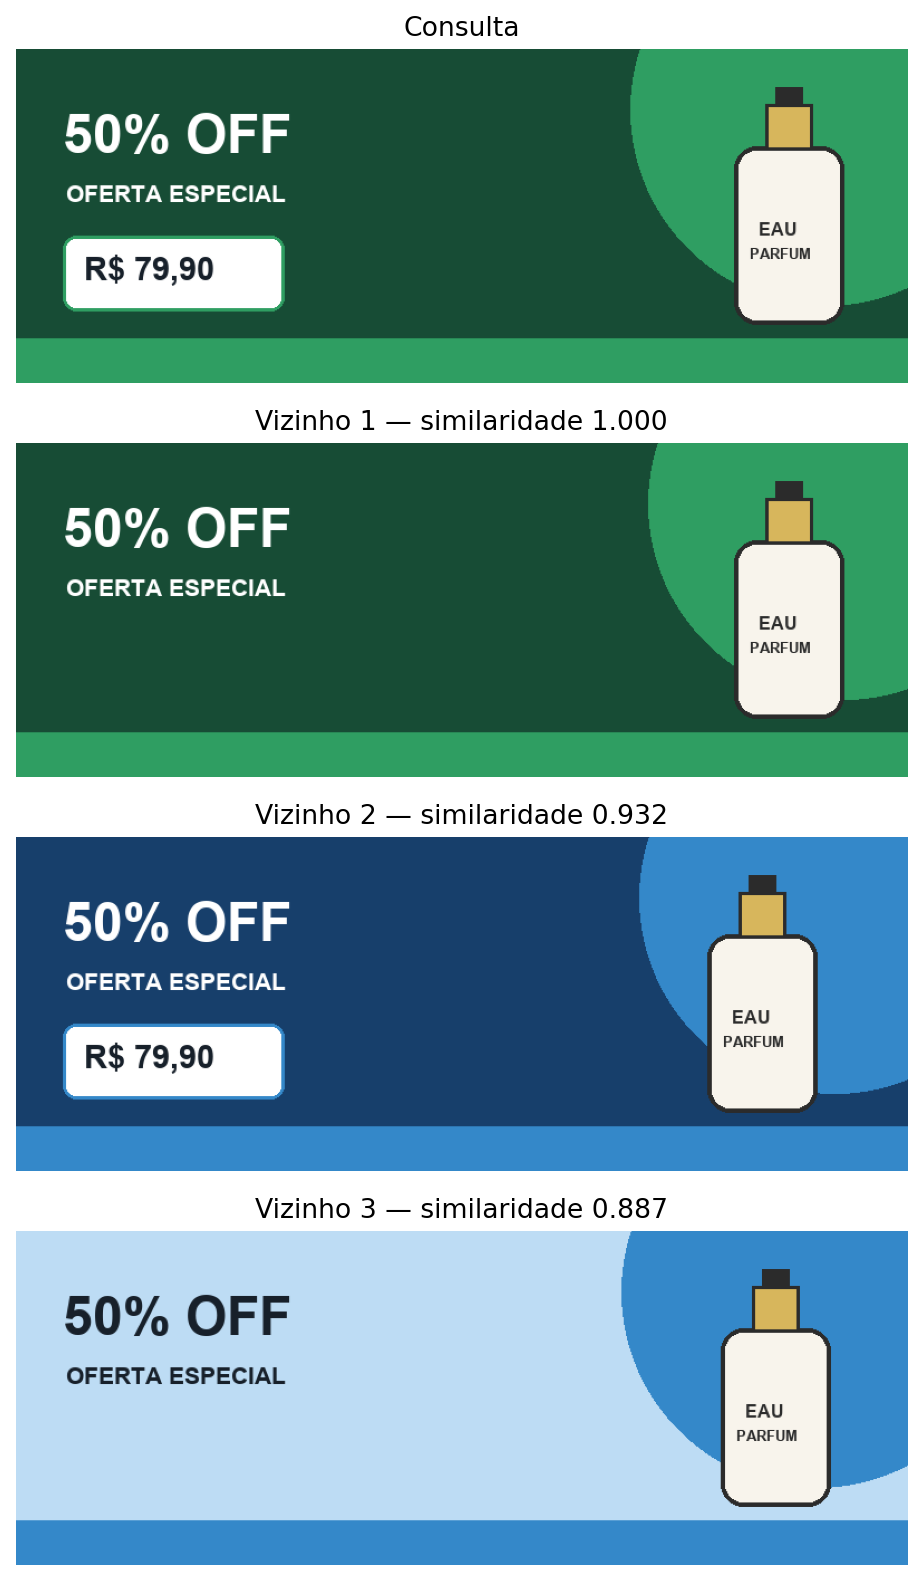

In [7]:
indices = vizinhos(emb, i=0, k=4)
print("Consulta e vizinhos:", indices.tolist())
plotar_vizinhos(caminhos, emb, i=0, k=3)
display(IPyImage(filename="reports/figures/clip_vizinhos.png"))

## Limite da demonstração

A demo valida componentes técnicos e permite inspecionar semântica e estilo. Como não há KPI de performance associado às imagens, isto não é um score de CTR ou receita. Esse aprendizado exige histórico de exposição e validação causal em teste A/B.